# TITLE AND OBJECTIVE

## 📧 Email Spam Classifier

##  Objective
The goal of this project is to build a machine learning model that can classify emails/messages as **Spam** or **Not Spam (Ham)**.

## Approach
- Data Cleaning
- Text Preprocessing
- Feature Extraction (TF-IDF)
- Model Training (Naive Bayes)
- Evaluation

##  Dataset
The dataset contains labeled messages categorized as spam or ham.

# Import Libraries

In [1]:
# Import core libraries for data handling
import numpy as np              # Numerical operations
import pandas as pd             # Data manipulation and analysis


# Import libraries for visualization
import matplotlib.pyplot as plt # Basic plotting
import seaborn as sns           # Enhanced data visualization


# Import libraries for text preprocessing (NLP)
import re                       # Text cleaning using regular expressions
import nltk                     # Natural Language Processing toolkit
from nltk.corpus import stopwords          # Common words to remove
from nltk.stem.porter import PorterStemmer # Word stemming (root form)


# Import machine learning utilities
from sklearn.model_selection import train_test_split   # Split data into train/test sets
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text to numerical features
from sklearn.naive_bayes import MultinomialNB          # Naive Bayes classifier for text data


# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score


# Download required NLTK data (run once)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/parnikasunda/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Dataset

In [2]:
# Load dataset with appropriate encoding to avoid decoding errors
df = pd.read_csv('spam.csv', encoding='latin-1')

# Display first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Data Cleaning

In [3]:
# Retain only relevant columns
df = df[['v1', 'v2']]

# Rename columns for clarity
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Encode Labels

In [4]:
# Convert categorical labels into numerical format
# ham → 0, spam → 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Basic Data Exploration

In [5]:
# Check class distribution
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

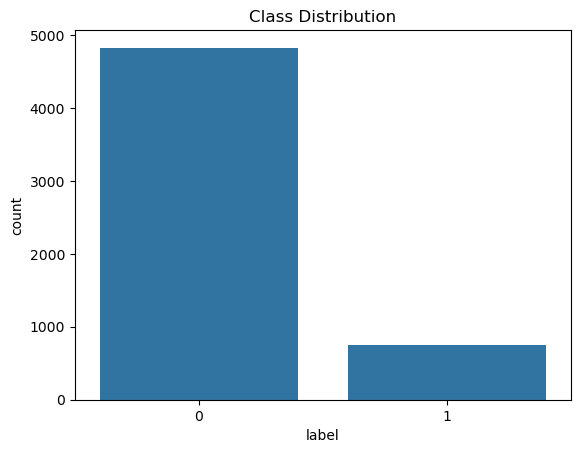

In [6]:
# Visualize distribution of spam vs ham
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.show()

# Feature Engineering

In [7]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/parnikasunda/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/parnikasunda/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
import nltk
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
nltk.download('stopwords')

df['num_characters'] = df['text'].apply(len)

df['num_words'] = df['text'].apply(lambda x: len(x.split()))

df['num_sentences'] = df['text'].apply(lambda x: len(sent_tokenize(x)))

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/parnikasunda/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/parnikasunda/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Text Preprocessing Function

In [9]:
# Initialize stemmer
ps = PorterStemmer()

def transform_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    # Tokenize text into words
    words = text.split()
    
    # Remove stopwords and apply stemming
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    
    return " ".join(words)

# Text Preprocessing

In [10]:
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    return " ".join(words)

# Apply Preprocessing

In [11]:
# Apply preprocessing to all messages
df['transformed_text'] = df['text'].apply(transform_text)

df.head()

,label,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,11,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe usf live around though


# Word Cloud

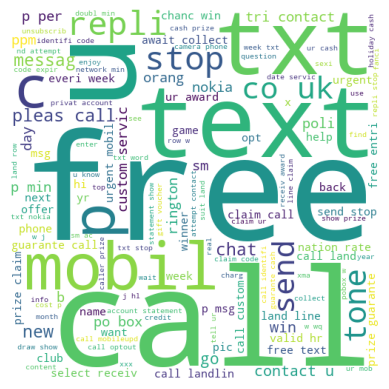

In [12]:
!pip install wordcloud
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['label'] == 1]['transformed_text'].str.cat(sep=" "))

plt.imshow(spam_wc)
plt.axis('off')
plt.show()

# Feature Extraction (TF-IDF)

In [13]:
# Convert text data into numerical feature vectors
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['label']

# Train-Test Split

In [14]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [15]:
# Initialize and train Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


# Prediction

In [16]:
# Generate predictions on test data
y_pred = model.predict(X_test)

# Evaluation

In [17]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)

Accuracy: 0.9748878923766816
Precision: 1.0


# Confusion Matrix

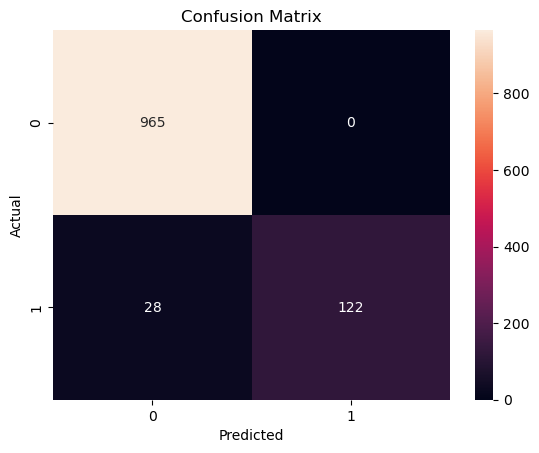

In [18]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Testing Custom Input

In [19]:
sample = ["Free entry in 2 a wkly comp to win FA Cup"]

sample_transformed = transform_text(sample[0])
sample_vector = tfidf.transform([sample_transformed])

prediction = model.predict(sample_vector)

print("Spam" if prediction[0] == 1 else "Not Spam")

Spam


In [20]:
msgs = [
    "Hey, are we meeting tomorrow?",
    "Win cash now!!! Click this link",
    "Your OTP is 456789",
    "Free entry in a contest, claim now"
]

for msg in msgs:
    msg_transformed = transform_text(msg)
    msg_vector = tfidf.transform([msg_transformed])
    result = model.predict(msg_vector)[0]
    
    print(msg, " --> ", "Spam" if result == 1 else "Not Spam")

Hey, are we meeting tomorrow?  -->  Not Spam
Win cash now!!! Click this link  -->  Spam
Your OTP is 456789  -->  Not Spam
Free entry in a contest, claim now  -->  Spam


# Final Conclusion

## Conclusion

The model successfully classifies spam messages using TF-IDF and Naive Bayes.

Feature engineering and preprocessing significantly improve performance.

## Future Scope

- Use advanced models (XGBoost, Random Forest)
- Apply deep learning (LSTM, BERT)
- Improve text cleaning techniques